In [30]:
import numpy as np
import math
import pandas as pd 
import scipy.stats as stats 
import matplotlib.pyplot as plt
from numba.typed import List
import itertools
from scipy.stats import linregress
from numba import njit
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from itertools import product

In [31]:

def give_all_comb(len):
    return [seq  for i, seq in enumerate(product([-1, 1], repeat=len))]


In [32]:
@njit
def seq_to_index(context):
    idx = 0
    for i in range(len(context)):
        idx = idx * 2 + (context[i] == 1)
    return idx

@njit
def homm_get_next_w(context_arr, memorySeq,memoryStrengthPlus, memoryStrengthMinus, order, gamma):
    act_pos = 0.0
    act_neg = 0.0
    lag_weights = np.exp(-gamma * (order - 1 - np.arange(order)))

    for i in range(len(memorySeq)):
        memory   = memorySeq[i]
        abs_dif  = lag_weights * np.abs(memory - context_arr)
        sim      = np.exp(-np.sum(abs_dif))
        strengthPlus = memoryStrengthPlus[i]
        strengthMinus = memoryStrengthMinus[i]

        act_pos += strengthPlus * sim
        act_neg += strengthMinus * sim  # negative -1 evidence → positive +1 evidence

    total = act_pos + act_neg
    if total > 0.0:
        return act_pos / total
    return 0.5

@njit
def homm_add_to_memory(context_arr,resp, confidence, memoryStrengthPlus, memoryStrengthMinus, decay):
    idx = seq_to_index(context_arr)
    memoryStrengthPlus *= decay
    memoryStrengthMinus *= decay

    if resp ==1:
        memoryStrengthPlus[idx] += confidence
    else:
        memoryStrengthMinus[idx] += confidence

@njit
def build_context(resp_arr, i, k):
    context = np.zeros(k, dtype=np.int64)
    start = max(i - k, 0)
    length = i - start
    for j in range(length):
        context[k - length + j] = resp_arr[start + j]
    return context

def normalize_weights(weights, k_w):

    weights = np.asarray(weights, dtype=float)
    target_sum = 2 ** (k_w - 1)
    weights = target_sum * weights / np.sum(weights)

    for _ in range(100):
        excess = np.maximum(0, weights - 1)
        if np.sum(excess) < 1e-12:
            break                                   # all weights in [0, 1]
        weights = np.minimum(weights, 1)            # clip
        good = weights < 1
        if not np.any(good):
            break                                   # no room to redistribute
        weights[good] += np.sum(excess) / np.sum(good)

    return weights

In [33]:
import numpy as np
from numba import njit
from scipy.stats import norm as _norm

# Pre-computed 5-point Gauss-Legendre nodes and weights on [-1, 1]
_GL5_NODES   = np.array([-0.9061798459386640, -0.5384693101056831,
                           0.0,
                           0.5384693101056831,  0.9061798459386640])
_GL5_WEIGHTS = np.array([ 0.2369268850561891,  0.4786286704993665,
                           0.5688888888888889,
                           0.4786286704993665,  0.2369268850561891])

@njit
def _norm_pdf(x):
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)

@njit
def _ddm_pdf_lower_core(t, v, a, w, sv, max_J=50, eps=1e-12):
    """
    Core lower-boundary PDF for a single (v, a, w) triple.
    σ is assumed = 1 here; caller must pre-scale v, a, sv by 1/σ.
    sv = inter-trial drift SD  (set 0 for no drift variability).
    w  = relative starting point in (0,1).
    """
    if t <= 0.0:
        return 1e-300
    if t < 1e-6:
        t = 1e-6

    one_plus = 1.0 + sv * sv * t
    denom = np.sqrt(t**3 * one_plus)

    expo = np.exp(
        (-(v * v) * t - 2.0 * v * a * w + (sv * sv) * (a * w) * (a * w))
        / (2.0 * one_plus)
    )

    sqrt_t = np.sqrt(t)
    s = 0.0
    prev_term = 0.0

    for j in range(max_J):
        if j % 2 == 0:
            rj = j * a + a * w
        else:
            rj = j * a + a * (1.0 - w)

        term = ((-1) ** j) * rj * _norm_pdf(rj / sqrt_t)
        s += term

        if j > 3 and np.abs(term) < eps and np.abs(prev_term) < eps:
            break
        prev_term = term

    pdf = (expo / denom) * s
    return max(pdf, 1e-300)


@njit
def ddm_pdf_lower_boundary(t, v, a, w, t0,
                            sv=0.0, sz=0.0, sigma=1.0,
                            max_J=50, eps=1e-12):
    """
    Lower-boundary PDF with:
      σ   (sigma)  – diffusion coefficient  [scales v, a, sv]
      sv           – inter-trial drift SD
      sz           – uniform starting-point range  w ~ Uniform(w-sz/2, w+sz/2)
                     integrated via 5-point Gauss-Legendre quadrature

    Reference for σ scaling:
        Blurton et al. (2017), J. Math. Psych. 76, 7-12  (eq. 1 footnote)
    Reference for sz quadrature approach:
        Ratcliff & Tuerlinckx (2002), Psychon. Bull. Rev. 9, 438-481
        (HDDM and fddm both implement sz this way in practice)
    """
    t_eff = t - t0
    if t_eff <= 0.0:
        return 1e-300

    # -------------------------------------------------------
    # σ handling: pure rescaling (σ is a scale parameter)
    # v/σ, a/σ, sv/σ are the normalised parameters
    # -------------------------------------------------------
    if sigma != 1.0:
        v  = v  / sigma
        a  = a  / sigma
        sv = sv / sigma

    # -------------------------------------------------------
    # sz = 0 → no starting-point variability, fast path
    # -------------------------------------------------------
    if sz <= 1e-10:
        return _ddm_pdf_lower_core(t_eff, v, a, w, sv, max_J, eps)

    # -------------------------------------------------------
    # sz > 0: Gauss-Legendre quadrature over
    #   w' ∈ [w - sz/2, w + sz/2]  (clipped to (0,1))
    #
    # (1/sz) ∫_{w-sz/2}^{w+sz/2} f(t|w') dw'
    #  = (1/2) Σ_i weight_i * f(t | w + (sz/2)*node_i)
    # -------------------------------------------------------
    # Hard-coded 5-point GL nodes and weights (on [-1, 1])
    n0 = -0.9061798459386640;  wt0 = 0.2369268850561891
    n1 = -0.5384693101056831;  wt1 = 0.4786286704993665
    n2 =  0.0;                 wt2 = 0.5688888888888889
    n3 =  0.5384693101056831;  wt3 = 0.4786286704993665
    n4 =  0.9061798459386640;  wt4 = 0.2369268850561891

    half_sz = sz * 0.5
    acc = 0.0

    for (node, wt) in ((n0, wt0), (n1, wt1), (n2, wt2), (n3, wt3), (n4, wt4)):
        w_prime = w + half_sz * node

        # Clip to valid range – avoid boundary singularities
        if w_prime <= 0.0:
            w_prime = 1e-6
        elif w_prime >= 1.0:
            w_prime = 1.0 - 1e-6

        acc += wt * _ddm_pdf_lower_core(t_eff, v, a, w_prime, sv, max_J, eps)

    pdf = 0.5 * acc          # factor 1/2 from change-of-variables
    return max(pdf, 1e-300)

def complete_run(data, params):
    vSlope,vPower,vBias,a,t0,w,lapse,sw,sv  = params


    return complete_run_fast(
        data["coherence"].to_numpy(np.float64),
        data["stim"].to_numpy(np.int8),
        data["response"].to_numpy(np.int8),
        data["rt"].to_numpy(np.float64),
        vSlope,vPower,vBias,a,t0,w,lapse,sw,sv
    )




@njit
def conf(v, tau=1.0):
    return 0.5 * (1.0 + math.erf(v * math.sqrt(tau) * 0.7071067811865476))
@njit
def complete_run_fast(coherence, stim, resp, rt,
                      vSlope,vPower,vBias,a,t0,w,lapse,sw,sv):
    n = len(stim)
    likelihood = 0.0

    for i in range(n):
        
        a_eff = a
        
        v_base = vSlope * coherence[i]**vPower
        
        v_signed = v_base if stim[i] == 1 else -v_base

        # Step 3: add directional bias AFTER sign
        # vBias > 0 always pushes toward stim==1 boundary
        v_biased = v_signed + vBias

        # Step 4: fold for response (DDM lower-boundary trick)
        if resp[i] == 1:   # chose right
            v_eff = v_biased
            w_eff = w
        else:              # chose left
            v_eff = -v_biased
            w_eff = 1.0 - w
        


        p_ddm   =  ddm_pdf_lower_boundary(rt[i], -v_eff, a_eff, 1.0-w_eff, t0,sz = sw,sv = sv)
        p_lapse = 0.5 / (4.0 - 0.15)
        p = (1.0 - lapse)*p_ddm + lapse*p_lapse
        if p > 0:
            likelihood += math.log(p)


    return likelihood

In [34]:
# est_parameters = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/ItrustNoLeak/NoTauAndWeightMemFixed.csv")
# for i in est_parameters["id"].unique():
#     pp_id = i



#     df = pd.read_csv("../data_all_subjects.csv")
#     df["orig_order"] = np.arange(len(df))

#     df = (
#         df.sort_values(["sj", "session", "orig_order"])
#         .reset_index(drop=True)
#     )


#     df_par = df[df["sj"]==pp_id]

    



#     participant_par = est_parameters[est_parameters["id"] == pp_id]

#     vPower   = float(participant_par["vPower"].iloc[0])
#     vSlope   = float(participant_par["vSlope"].iloc[0])
#     aA = float(participant_par["aS"].iloc[0])
#     t0       = float(participant_par["t0"].iloc[0])
#     w        = float(participant_par["w"].iloc[0])
#     k        = int(participant_par["k"].iloc[0]) 
#     d        = float(participant_par["d"].iloc[0])
#     weight_w = float(participant_par["weight_w"].iloc[0])
#     weight_v = float(participant_par["weight_v"].iloc[0])
#     gamma    = float(participant_par["gamma"].iloc[0])
#     lapse    = float(participant_par["lapse"].iloc[0])



#     params = vSlope,vPower,aA,t0,w,k,d,weight_w,weight_v,lapse,gamma,0.5,0.0,0.0


#     likelihood = complete_run(df_par,params)
#     print(likelihood - float(participant_par["max_log_lik"].iloc[0]))

In [35]:
# ps = list(ps)
# seqs = dict({seq:[] for seq in give_all_comb(k)})
# for i in range(len(ps)):
#     if 0 not in contexts[i]:
#         seqs[tuple(contexts[i])].append((i,ps[i]))

In [36]:
# for key in seqs.keys():
#     l=seqs[key]
#     time = [i for (i,ppos) in l]
#     ps = [ppos for (i,ppos) in l]
#     plt.plot(time,ps,label = f"{key}")
#     plt.legend()

In [37]:
import numpy as np
import cma

def fit_mle(df_participant, n_restarts=10, k_values=range(1, 2)):

    best_overall = {"params": None, "k": None, "neg_ll": np.inf}

    print(f"Running optimization for k = {list(k_values)}")

    for k in k_values:
        k_w = min(3,k)
        bounds_low  = [0.1, 0.1,-10.0, 0.1, 0.0, 0.3, 0.0, 0.0, 0.0]
        bounds_high = [20.0, 20.0,10.0, 3.0, 0.5, 0.7, 1.0, 1.0, 3.0]
        param_names = ["vSlope","vPower","vBias","a","t0","w","lapse","sw","sv"] 

        print(f"\n=== Optimizing with fixed k = {k} ===")

        def neg_log_lik(params):
            # clip to bounds — CMA-ES can wander outside them
            params = np.clip(params, bounds_low, bounds_high)
            vSlope,vPower,vBias,a,t0,w,lapse,sw,sv  =   params

            full_params = (vSlope,vPower,vBias,a,t0,w,lapse,sw,sv)
            ll = -complete_run(df_participant, full_params)
            return ll if np.isfinite(ll) else 1e10

        best_k_params = None
        best_k_val    = np.inf
        successful_fits = 0

        for i in range(n_restarts):
            # random start point inside bounds
            x0 = np.array([np.random.uniform(lo, hi) 
                           for lo, hi in zip(bounds_low, bounds_high)])

            # initial step size — roughly 1/4 of parameter range
            sigma0 = np.mean([(hi - lo) / 4 
                              for lo, hi in zip(bounds_low, bounds_high)])

            opts = cma.CMAOptions()
            opts['bounds']      = [bounds_low, bounds_high]
            opts['maxiter']     = 1000 
            opts['tolx']        = 1e-8
            opts['tolfun']      = 1e-8
            opts['verbose']     = -9   # silent
            opts['seed']        = np.random.randint(0, 100000)

            try:
                es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
                es.optimize(neg_log_lik)
                result = es.result

                if np.isfinite(result.fbest):
                    successful_fits += 1
                    if result.fbest < best_k_val:
                        best_k_val    = result.fbest
                        best_k_params = np.clip(result.xbest, bounds_low, bounds_high)
                        print(f"  Restart {i+1}: New best LL = {-best_k_val:.2f}")
                        print(f"  Params: {best_k_params}")

            except Exception as e:
                print(f"  Restart {i+1} failed: {e}")
                continue

        print(f"  Successful fits for k={k}: {successful_fits}/{n_restarts}")

        if best_k_params is not None and best_k_val < best_overall["neg_ll"]:
            best_overall["neg_ll"]  = best_k_val
            best_k_params = list(best_k_params)


            maxk = (list(k_values))[-1]
            
            weights = np.asarray(best_k_params[-2**k_w:])
            weights = normalize_weights(weights, k_w)

            for_save = list(best_k_params[:-2**k_w]) + list(weights)
            print((for_save))
            
            best_overall["params"]  = np.asarray(for_save + [-1.0 for i in range(2**k,2**3)])
            best_overall["params"]  = best_k_params
            best_overall["k"]       = k

    if best_overall["params"] is not None:
        print("\n=== Best overall fit ===")
        print(f"k = {best_overall['k']}")
        for name, val in zip(param_names, best_overall["params"]):
            print(f"  {name}: {val:.4f}")
        print(f"Final Log-Likelihood: {-best_overall['neg_ll']:.2f}")
        return best_overall["params"], best_overall["k"], -best_overall["neg_ll"]
    else:
        print("No successful fits found!")
        return None, None, None

In [38]:



def fit_all_participants(df_path, output_path=None, test_first_n=None):
    """Fit RDM to all participants"""
    
    # Load data
    df = pd.read_csv(df_path)
    df["orig_order"] = np.arange(len(df))

    df = (
        df.sort_values(["sj", "session", "orig_order"])
        .reset_index(drop=True)
    )



    print(f"Loaded data with {len(df)} rows")
    print(f"Unique participants: {df['sj'].nunique()}")
    print(f"Columns: {list(df.columns)}")
    
    # Check data structure
    print("\nData preview:")
    print(df.head())
    
    # Initialize results list
    results = []
    
    # Get participant list
    participants = df['sj'].unique()
    if test_first_n:
        participants = participants[:test_first_n]
        print(f"Testing first {test_first_n} participants only")

    
    # Loop over participants
    for i, participant_id in enumerate(participants):
        print(f"\n{'='*50}")
        print(f"Fitting participant {participant_id} ({i+1}/{len(participants)})")
        print(f"{'='*50}")
        
        participant_df = df[df['sj'] == participant_id]
        print(f"Participant has {len(participant_df)} trials")
        

        params,k, max_ll = fit_mle(participant_df, n_restarts=4)  # Fewer restarts for testing
        
        if params is not None:
            results.append([participant_id] + list(params) + [max_ll])
            print(f"✓ Success: LL = {max_ll:.2f}")
        else:
            results.append([participant_id] + [None] * 11 + [None])
            print("✗ Failed: No valid fit found")
                
    
    # Create results DataFrame
    columns = ["id","vSlope","vPower","vBias","a","t0","w","lapse","sw","sv", "max_log_lik"]

    results_df = pd.DataFrame(results, columns=columns)

    print(f"\nParameter summary (successful fits only):")
    numeric_cols = columns

    print(results_df[numeric_cols].describe())
    
    # Save results
    if output_path:
        results_df.to_csv(output_path, index=False)
        print(f"\nResults saved to: {output_path}")
    
    return results_df

# Example usage:
if __name__ == "__main__":
    # Test with first few participants only
    results_df = fit_all_participants(
        df_path="../data_all_subjects.csv",
        output_path="PureDDM.csv",
        test_first_n=25  # Test with first 3 participants only
    )
    
    print("\nFirst few results:")
    print(results_df)

Loaded data with 78201 rows
Unique participants: 22
Columns: ['Unnamed: 0', 'sj', 'condition', 'session', 'block', 'coherence', 'stim', 'response', 'rt', 'orig_order']

Data preview:
   Unnamed: 0   sj condition  session  block  coherence  stim  response  \
0           0  1.0   Neutral      1.0    1.0        0.6   1.0       1.0   
1           1  1.0   Neutral      1.0    1.0        0.0   1.0      -1.0   
2           2  1.0   Neutral      1.0    1.0        0.0   1.0      -1.0   
3           3  1.0   Neutral      1.0    1.0        0.4  -1.0      -1.0   
4           4  1.0   Neutral      1.0    1.0        0.4  -1.0      -1.0   

      rt  orig_order  
0  0.319           0  
1  0.433           1  
2  0.500           2  
3  0.267           3  
4  0.317           4  
Testing first 25 participants only

Fitting participant 1.0 (1/22)
Participant has 3408 trials
Running optimization for k = [1]

=== Optimizing with fixed k = 1 ===
  Restart 1: New best LL = 853.63
  Params: [4.35449914e+00 7.0

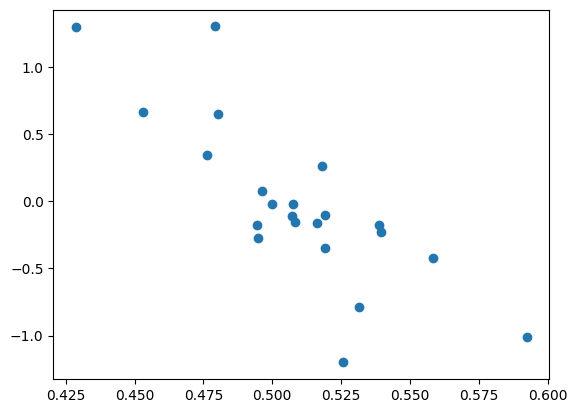

In [42]:
df=pd.read_csv("PureDDM.csv")
import matplotlib.pyplot as plt 
plt.scatter(df["w"],df["vBias"])

In [39]:
df =  pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/ABNoDecay/ProperPrior.csv")
df2 =  pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/Alpha Beta/ProperPrior.csv")
df_uden_lambda = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/Alpha Beta/RespMemory.csv") 
df_no_fat = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/Alpha Beta/AlphaBetaBias.csv")
np.sum(round(((df["max_log_lik"] - df2["max_log_lik"])),2))

-493.98

In [40]:
import pandas as pd 
df =  pd.read_csv("NoDecayTrueNTestedMax8FreeW.csv")
df["ws_total"] = df.apply(lambda row: sum(row[df.columns[13:-3]]),axis = 1)
# for w in df.columns[13:-3]:
#     df[w] = df[w]*4/df["ws_total"]

df["ws_total"] = df.apply(lambda row: sum(row[df.columns[13:-3]]),axis = 1)
round(df[["weight_w"]+["w"]+["bias_strength"]+["ws_total"]+list(df.columns[13:-3])],2)

FileNotFoundError: [Errno 2] No such file or directory: 'NoDecayTrueNTestedMax8FreeW.csv'

In [ ]:
round(df["d"],2)

KeyError: 'd'

In [ ]:
df = pd.read_csv("/Users/Anton/Desktop/BachelorProjekt/UraiData/Final/PureDDM.csv")
round(df["fattigue"]*3000,2)

0     0.00
1     0.50
2     0.25
3     0.00
4     0.23
5     0.17
6     0.08
7     0.51
8     0.65
9     0.00
10    0.57
11    0.28
12    0.00
13    0.00
14    1.41
15    0.52
16    0.23
17    0.48
18    0.81
19    0.74
20    0.57
21    0.07
Name: fattigue, dtype: float64

In [ ]:
for i in range(6):
    print(29.9*(0.1*i)**0.47)
